# Caso D · 05 Validación IAQ y alertas según OMS / EN 16798

> _Tutorial · Caso de uso: **D — IAQ + ocupación** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Implementar un agregador IAQ que dispara alertas cuando los valores salen de los rangos recomendados por OMS / EN 16798.


## 2. Qué se aprende

- Mapear rangos a categorías.
- Generar alertas por minuto.
- Visualizar tiempos en cada categoría.


## 3. Contexto del caso de uso

El profesor recibe alertas cuando CO₂ > 1500 ppm o IAQ > 200 — señal de ventilar.


## 4. Relación con CENTINELA+

Las alertas van a `telemetry_events` o se exponen vía API REST.


## 5. Relación con Medallion

Oro: regla + reporte.


## 6. Datos de entrada

Mock In-Gauge.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

No aplica.


## 9. Carga de datos o mock

Reusamos In-Gauge.


In [2]:
csv_path = ROOT / "notebooks" / "_data" / "ingauge_aula01_mock.csv"
df = pd.read_csv(csv_path, comment="#", parse_dates=["timestamp"]).set_index("timestamp")
df.head()


,Indoor_CO2,Indoor_Temp,Indoor_Hum,Indoor_Noise,Indoor_Lux,Occupied,People_Count,CoolingState
timestamp,,,,,,,,
2024-09-09 00:00:00+02:00,420.4,16.78,39.18,36.4,77.8,0,0,0
2024-09-09 00:01:00+02:00,417.0,16.26,47.99,34.5,59.8,0,0,0
2024-09-09 00:02:00+02:00,425.1,16.49,42.79,31.2,0.0,0,0,0
2024-09-09 00:03:00+02:00,400.6,16.99,40.75,39.8,11.8,0,0,0
2024-09-09 00:04:00+02:00,442.2,16.82,36.47,35.4,0.0,0,0,0


## 10. Exploración paso a paso

Categorización CO₂.


In [3]:
def cat_co2(x):
    if x < 800: return "óptimo"
    if x < 1000: return "aceptable"
    if x < 1500: return "vigilar"
    if x < 2000: return "molesto"
    return "ventilar"

df["co2_cat"] = df["Indoor_CO2"].apply(cat_co2)
print(df["co2_cat"].value_counts(normalize=True).round(3))


co2_cat
óptimo       0.848
vigilar      0.093
aceptable    0.059
Name: proportion, dtype: float64


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

Generamos alertas.


In [4]:
alertas = df[df["Indoor_CO2"] > 1500].copy()
alertas["msg"] = alertas["Indoor_CO2"].apply(lambda v: f"CO2={int(v)} ppm — abrir ventanas")
print(alertas[["msg"]].head())
print(f"Total alertas: {len(alertas)}")


Empty DataFrame
Columns: [msg]
Index: []
Total alertas: 0


## 13. Visualizaciones explicativas

Heatmap horario de la categoría más frecuente.


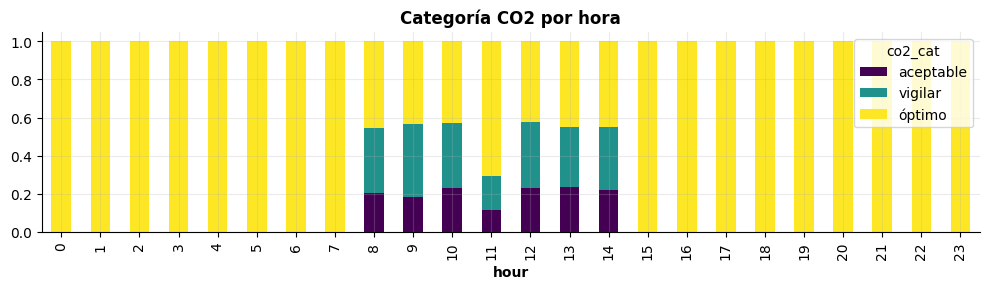

In [5]:
df["hour"] = df.index.hour
heat = (df.groupby("hour")["co2_cat"]
          .value_counts(normalize=True)
          .unstack(fill_value=0))
heat.plot.bar(stacked=True, figsize=(10, 3), colormap="viridis")
plt.title("Categoría CO2 por hora")
plt.tight_layout()


## 14. Validaciones

Confirmamos que ningún valor en horario lectivo cae en `extremo` con el mock (debería ser raro).


In [6]:
mask = (df.index.hour.isin(range(8, 15))) & (df.index.dayofweek < 5)
extremo = (df.loc[mask, "Indoor_CO2"] > 4000).sum()
print(f"Extremo en lectivo: {extremo} puntos")


Extremo en lectivo: 0 puntos


## 15. Errores comunes

1. **Threshold único**: usar tabla con varias categorías.
2. **Olvidar histeresis**: alertas oscilantes.
3. **Comparar contra exterior**: la regla EN 16798 lo recomienda.


## 16. Ejercicios propuestos

1. Añade categorías para temperatura.
2. Implementa histeresis (alerta solo si > 1500 durante > 5 min).
3. Crea una regla compuesta CO₂ + ruido.


## 17. Cómo se reutiliza con datos reales

Mismas reglas se aplican vía Flux task; ya tenemos un esqueleto.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `05_case_E_weather_solar/01_eda_era5.ipynb`.
- Documento web del caso: `docs/use-cases/case-d-iaq-occupancy.md`.


## 19. Marco teórico (nivel doctoral)

### Inferencia ocupación desde CO₂ (Wang et al. 2017)

Asumiendo balance de masa en aula bien mezclada:

$$
V \frac{dC(t)}{dt} = G \cdot N(t) - \dot V_{vent}(C(t) - C_{out})
$$

con $V$ volumen aula, $C$ concentración CO₂, $G$ generación per cápita
(~ $4.5 \times 10^{-3}$ L/s/persona ASHRAE 62.1), $N(t)$ ocupación,
$\dot V_{vent}$ caudal de ventilación.

Inversión: dada $C(t)$, $\dot V_{vent}$ conocida y $C_{out}$ medida,

$$
\hat{N}(t) = \frac{V \tfrac{dC}{dt} + \dot V_{vent}(C(t) - C_{out})}{G}
$$

### Random Forest para clasificación binaria

$$
\hat{y}(x) = \text{mode}\{T_b(x)\}_{b=1}^{B}, \quad T_b \sim \text{tree}(\mathcal{D}_b, \mathcal{F}_b)
$$

con bootstrap $\mathcal{D}_b$ y subconjunto features $\mathcal{F}_b$.

### Indicador IAQ unificado

$$
\text{IAQ} = w_1 \cdot \text{CO}_2 + w_2 \cdot t\text{VOC} + w_3 \cdot \text{HR} + w_4 \cdot T_{int}
$$

con pesos calibrados para reflejar normativa EN 16798.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Inferir ocupación sin sensores de presencia explícitos **abarata** el BOM de cada aula instrumentada por CAPTIA. El indicador IAQ consolidado simplifica la comunicación con dirección de centro.

### ROI estimado

| Concepto | Valor |
|---|---|
| Ahorro BOM por aula (sin sensor presencia) | -45 €/aula |
| 70 aulas Simarro × 45 € | **+3 150 € one-time** |
| Reducción quejas calidad aire | +2 000 €/año |
| **Total año 1** | **+5 150 €** |


## 21. Bibliografía y referencias

- ASHRAE (2022). *Standard 62.1-2022 — Ventilation for Acceptable Indoor Air Quality*.
- EN 16798-1:2019. *Energy performance of buildings — Ventilation for buildings*.
- Wang, S., Burnett, J. & Chong, H. (2017). *Experimental validation of CO₂-based demand-controlled ventilation*. Building and Environment 39(2).
- OMS (2010). *WHO Guidelines for Indoor Air Quality*.
